In [2]:
# ==========================================
# MediScan — Day 10: Grad-CAM
# Cell 1 — Environment & Project Verification
# ==========================================

from pathlib import Path
import torch
import os

# -----------------------------
# 1. Mount Google Drive
# -----------------------------
from google.colab import drive

drive.mount("/content/drive")

# -----------------------------
# 2. Project directories
# -----------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"

DAY8_MODEL_PATH = MODELS_DIR / "efficientnet_b0_best_day8.pth"

# -----------------------------
# 3. Verify project
# -----------------------------
print("=" * 55)
print("MEDISCAN — DAY 10 GRAD-CAM")
print("=" * 55)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nProject exists:", PROJECT_DIR.exists())

print("\nProject contents:")
if PROJECT_DIR.exists():
    for item in sorted(PROJECT_DIR.iterdir()):
        print("→", item.name)

# -----------------------------
# 4. Verify important paths
# -----------------------------
print("\n" + "=" * 55)
print("PATH VERIFICATION")
print("=" * 55)

print("Models directory :", MODELS_DIR.exists())
print("Raw data         :", RAW_DIR.exists())
print("Processed data   :", PROCESSED_DIR.exists())
print("Figures directory:", FIGURES_DIR.exists())
print("Reports directory:", REPORTS_DIR.exists())

print("\nDay 8 model:")
print(DAY8_MODEL_PATH)
print("Exists:", DAY8_MODEL_PATH.exists())

# -----------------------------
# 5. Verify device
# -----------------------------
print("\n" + "=" * 55)
print("DEVICE VERIFICATION")
print("=" * 55)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is not available.")

print("\n" + "=" * 55)
print("CELL 1 VERIFICATION COMPLETE")
print("=" * 55)

Mounted at /content/drive
MEDISCAN — DAY 10 GRAD-CAM

Project directory:
/content/drive/MyDrive/MediScan

Project exists: True

Project contents:
→ data
→ figures
→ models
→ reports

PATH VERIFICATION
Models directory : True
Raw data         : True
Processed data   : True
Figures directory: True
Reports directory: True

Day 8 model:
/content/drive/MyDrive/MediScan/models/efficientnet_b0_best_day8.pth
Exists: True

DEVICE VERIFICATION
PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4

CELL 1 VERIFICATION COMPLETE


In [3]:
# ==========================================
# Cell 2 — Load Day 8 EfficientNet-B0 Model
# Self-contained version
# ==========================================

from pathlib import Path
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

# ------------------------------------------
# 1. Recreate required paths/device
# ------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")
MODELS_DIR = PROJECT_DIR / "models"

DAY8_MODEL_PATH = MODELS_DIR / "efficientnet_b0_best_day8.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------
# 2. Verify checkpoint
# ------------------------------------------

print("=" * 55)
print("DAY 8 MODEL VERIFICATION")
print("=" * 55)

print("Model path:", DAY8_MODEL_PATH)
print("Exists:", DAY8_MODEL_PATH.exists())
print("Device:", device)

if not DAY8_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Day 8 model not found at:\n{DAY8_MODEL_PATH}"
    )

# ------------------------------------------
# 3. Load checkpoint
# ------------------------------------------

checkpoint = torch.load(
    DAY8_MODEL_PATH,
    map_location=device
)

print("\n" + "=" * 55)
print("CHECKPOINT INFORMATION")
print("=" * 55)

print("Checkpoint keys:")
print(list(checkpoint.keys()))

print("\nArchitecture :", checkpoint.get("architecture"))
print("Num classes  :", checkpoint.get("num_classes"))
print("Dropout      :", checkpoint.get("dropout"))
print("Learning rate:", checkpoint.get("learning_rate"))
print("Batch size   :", checkpoint.get("batch_size"))
print("Augmentation :", checkpoint.get("augmentation"))

class_to_idx = checkpoint["class_to_idx"]

print("\nClass mapping:")
print(class_to_idx)

# ------------------------------------------
# 4. Recreate EfficientNet-B0
# ------------------------------------------

model = efficientnet_b0(weights=None)

num_classes = checkpoint["num_classes"]
dropout_rate = checkpoint["dropout"]

model.classifier = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
)

# ------------------------------------------
# 5. Load trained weights
# ------------------------------------------

model.load_state_dict(
    checkpoint["model_state_dict"]
)

# ------------------------------------------
# 6. Move model to device
# ------------------------------------------

model = model.to(device)
model.eval()

# ------------------------------------------
# 7. Create class names safely
# ------------------------------------------

class_names = [
    name for name, idx
    in sorted(class_to_idx.items(), key=lambda x: x[1])
]

# ------------------------------------------
# 8. Final verification
# ------------------------------------------

print("\n" + "=" * 55)
print("MODEL VERIFICATION")
print("=" * 55)

print("Model:", checkpoint["architecture"])
print("Device:", next(model.parameters()).device)
print("Training mode:", model.training)

print("Class names:", class_names)

print("\nClassifier:")
print(model.classifier)

print("\n✓ Day 8 model loaded successfully")
print("✓ Class names defined")
print("✓ Model ready for Grad-CAM")

DAY 8 MODEL VERIFICATION
Model path: /content/drive/MyDrive/MediScan/models/efficientnet_b0_best_day8.pth
Exists: True
Device: cuda

CHECKPOINT INFORMATION
Checkpoint keys:
['model_state_dict', 'architecture', 'num_classes', 'class_to_idx', 'learning_rate', 'batch_size', 'dropout', 'augmentation', 'epochs', 'best_epoch', 'best_val_accuracy', 'best_val_loss']

Architecture : EfficientNet-B0
Num classes  : 4
Dropout      : 0.1
Learning rate: 0.002
Batch size   : 32
Augmentation : weak

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

MODEL VERIFICATION
Model: EfficientNet-B0
Device: cuda:0
Training mode: False
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']

Classifier:
Sequential(
  (0): Dropout(p=0.1, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)

✓ Day 8 model loaded successfully
✓ Class names defined
✓ Model ready for Grad-CAM


In [4]:
# ==========================================
# Cell 3 — Grad-CAM Setup
# ==========================================

import sys
import subprocess

# ------------------------------------------
# 1. Verify / install Grad-CAM
# ------------------------------------------

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

    print("✓ pytorch-grad-cam is available")

except ImportError:
    print("Installing pytorch-grad-cam...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "grad-cam"
    ])

    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

    print("✓ pytorch-grad-cam installed successfully")


# ------------------------------------------
# 2. Inspect EfficientNet-B0 feature layers
# ------------------------------------------

print("\n" + "=" * 55)
print("EFFICIENTNET-B0 FEATURE STRUCTURE")
print("=" * 55)

print(model.features)


# ------------------------------------------
# 3. Select final convolutional feature layer
# ------------------------------------------

target_layer = model.features[-1]

print("\n" + "=" * 55)
print("GRAD-CAM TARGET LAYER")
print("=" * 55)

print("Target layer:")
print(target_layer)

print("\nTarget layer type:")
print(type(target_layer).__name__)

print("\n✓ Grad-CAM setup complete")
print("✓ Target convolutional feature layer selected")

Installing pytorch-grad-cam...
✓ pytorch-grad-cam installed successfully

EFFICIENTNET-B0 FEATURE STRUCTURE
Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
  

In [5]:
# ==========================================
# Cell 4 — Restore Test Dataset & DataLoader
# ==========================================

from pathlib import Path
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------
# 1. Recreate paths
# ------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
DRIVE_RAW_DIR = PROJECT_DIR / "data" / "raw"

LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

TEST_CSV = PROCESSED_DIR / "test.csv"

# ------------------------------------------
# 2. Restore local raw dataset if needed
# ------------------------------------------

print("=" * 55)
print("RAW DATA VERIFICATION")
print("=" * 55)

local_image_count = (
    len(list(LOCAL_RAW_DIR.rglob("*")))
    if LOCAL_RAW_DIR.exists()
    else 0
)

print("Local raw directory:", LOCAL_RAW_DIR)
print("Local files found:", local_image_count)

if local_image_count < 7000:
    print("\nLocal dataset incomplete.")
    print("Restoring raw dataset from Google Drive...")

    import shutil

    if LOCAL_RAW_DIR.exists():
        shutil.rmtree(LOCAL_RAW_DIR)

    LOCAL_RAW_DIR.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copytree(
        DRIVE_RAW_DIR,
        LOCAL_RAW_DIR
    )

    print("✓ Raw dataset restored")

else:
    print("✓ Local raw dataset already available")


# ------------------------------------------
# 3. Load test CSV
# ------------------------------------------

if not TEST_CSV.exists():
    raise FileNotFoundError(
        f"Test CSV not found:\n{TEST_CSV}"
    )

test_df = pd.read_csv(TEST_CSV)

print("\n" + "=" * 55)
print("TEST CSV VERIFICATION")
print("=" * 55)

print("Test samples:", len(test_df))
print("Columns:", list(test_df.columns))
print("\nClass distribution:")
print(test_df["label"].value_counts())


# ------------------------------------------
# 4. Evaluation transform
# ------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------
# 5. Define Dataset from scratch
# ------------------------------------------

class BrainMRIDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        local_raw_dir=None,
        class_to_idx=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.local_raw_dir = Path(local_raw_dir)

        if class_to_idx is None:
            raise ValueError(
                "class_to_idx must be provided."
            )

        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # CSV contains class name, NOT integer
        label_name = row["label"]

        if label_name not in self.class_to_idx:
            raise ValueError(
                f"Unknown label: {label_name}"
            )

        label = self.class_to_idx[label_name]

        # Get filename from CSV path
        filename = Path(
            str(row["image_path"])
        ).name

        # Search local dataset
        matches = list(
            self.local_raw_dir.rglob(filename)
        )

        if len(matches) == 0:
            raise FileNotFoundError(
                f"Image not found: {filename}"
            )

        image_path = matches[0]

        # Load RGB image
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )


# ------------------------------------------
# 6. Create test dataset
# ------------------------------------------

test_dataset = BrainMRIDataset(
    dataframe=test_df,
    transform=eval_transform,
    local_raw_dir=LOCAL_RAW_DIR,
    class_to_idx=class_to_idx
)


# ------------------------------------------
# 7. Create DataLoader
# ------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)


# ------------------------------------------
# 8. Verification
# ------------------------------------------

print("\n" + "=" * 55)
print("TEST DATALOADER VERIFICATION")
print("=" * 55)

print("Dataset size :", len(test_dataset))
print("Batch size   :", test_loader.batch_size)
print("Num batches  :", len(test_loader))

images, labels = next(iter(test_loader))

print("\nBatch:")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)
print("Unique labels:", sorted(labels.unique().tolist()))

print("\n✓ Test Dataset restored")
print("✓ Test DataLoader restored")
print("✓ Labels correctly mapped from class names")

RAW DATA VERIFICATION
Local raw directory: /content/MediScan/data/raw
Local files found: 0

Local dataset incomplete.
Restoring raw dataset from Google Drive...
✓ Raw dataset restored

TEST CSV VERIFICATION
Test samples: 1080
Columns: ['image_path', 'label', 'source']

Class distribution:
label
meningioma    270
notumor       270
glioma        270
pituitary     270
Name: count, dtype: int64

TEST DATALOADER VERIFICATION
Dataset size : 1080
Batch size   : 32
Num batches  : 34

Batch:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64
Unique labels: [0, 1, 2, 3]

✓ Test Dataset restored
✓ Test DataLoader restored
✓ Labels correctly mapped from class names


SINGLE SAMPLE PREDICTION
True label      : meningioma
Predicted label : meningioma
Confidence      : 0.6565



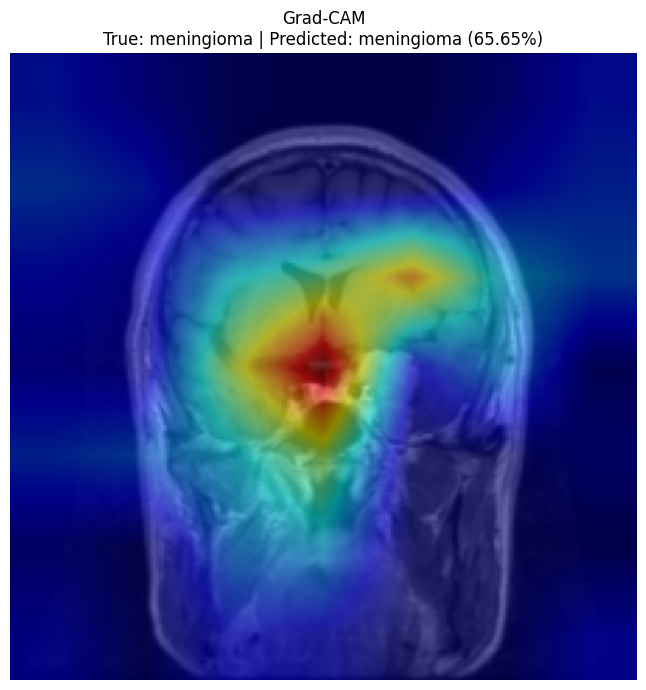

GRAD-CAM VERIFICATION
CAM shape       : (224, 224)
CAM min         : 0.0
CAM max         : 0.9999999
Overlay shape   : (224, 224, 3)

✓ Grad-CAM generated successfully
✓ Heatmap overlay generated successfully


In [6]:
# ============================================================
# DAY 10 — SINGLE SAMPLE GRAD-CAM VERIFICATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------
# 1. Restore required variables
# ------------------------------------------------------------

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 2. Get one test sample
# ------------------------------------------------------------

sample_images, sample_labels = next(iter(test_loader))

input_tensor = sample_images[0:1].to(device)
true_label = sample_labels[0].item()

# ------------------------------------------------------------
# 3. Model prediction
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)

predicted_class = probabilities.argmax(dim=1).item()
confidence = probabilities[0, predicted_class].item()

print("=" * 60)
print("SINGLE SAMPLE PREDICTION")
print("=" * 60)

print("True label      :", class_names[true_label])
print("Predicted label :", class_names[predicted_class])
print("Confidence      :", f"{confidence:.4f}")
print()

# ------------------------------------------------------------
# 4. Create Grad-CAM
# ------------------------------------------------------------

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

targets = [
    ClassifierOutputTarget(predicted_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

# ------------------------------------------------------------
# 5. Convert normalized tensor back to RGB image
# ------------------------------------------------------------

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

rgb_image = sample_images[0].permute(1, 2, 0).cpu().numpy()

rgb_image = rgb_image * std + mean
rgb_image = np.clip(rgb_image, 0, 1)

# ------------------------------------------------------------
# 6. Create heatmap overlay
# ------------------------------------------------------------

visualization = show_cam_on_image(
    rgb_image.astype(np.float32),
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# 7. Display result
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.imshow(visualization)
plt.title(
    f"Grad-CAM\n"
    f"True: {class_names[true_label]} | "
    f"Predicted: {class_names[predicted_class]} "
    f"({confidence:.2%})"
)

plt.axis("off")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Verification
# ------------------------------------------------------------

print("=" * 60)
print("GRAD-CAM VERIFICATION")
print("=" * 60)

print("CAM shape       :", grayscale_cam.shape)
print("CAM min         :", grayscale_cam.min())
print("CAM max         :", grayscale_cam.max())
print("Overlay shape   :", visualization.shape)

print()
print("✓ Grad-CAM generated successfully")
print("✓ Heatmap overlay generated successfully")

In [7]:
# ============================================================
# DAY 10 — GENERATE 12 GRAD-CAM EXPLAINABILITY SAMPLES
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------
# 1. Restore required variables
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()

# ------------------------------------------------------------
# 2. Create Grad-CAM object
# ------------------------------------------------------------

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

# ------------------------------------------------------------
# 3. Select 3 samples from each class
# ------------------------------------------------------------

selected_samples = []

for class_idx, class_name in enumerate(class_names):

    class_indices = [
        i for i, label in enumerate(test_df["label"])
        if label == class_name
    ]

    # Take first 3 samples from each class
    selected_samples.extend(class_indices[:3])

print("=" * 60)
print("GRAD-CAM SAMPLE SELECTION")
print("=" * 60)

print("Total samples selected:", len(selected_samples))

for class_name in class_names:
    count = sum(
        test_df.iloc[i]["label"] == class_name
        for i in selected_samples
    )
    print(f"{class_name:12s}: {count}")

# ------------------------------------------------------------
# 4. Generate Grad-CAM samples
# ------------------------------------------------------------

results = []

for sample_number, dataset_idx in enumerate(selected_samples, start=1):

    # Get image and true label
    input_image, true_label_tensor = test_dataset[dataset_idx]

    true_label = true_label_tensor.item()

    input_tensor = input_image.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

    # --------------------------------------------------------
    # Grad-CAM for predicted class
    # --------------------------------------------------------

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # --------------------------------------------------------
    # Denormalize image
    # --------------------------------------------------------

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    rgb_image = input_image.permute(1, 2, 0).cpu().numpy()

    rgb_image = rgb_image * std + mean
    rgb_image = np.clip(rgb_image, 0, 1)

    # --------------------------------------------------------
    # Create overlay
    # --------------------------------------------------------

    visualization = show_cam_on_image(
        rgb_image.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    filename = (
        f"day10_gradcam_sample_{sample_number:02d}_"
        f"{class_names[true_label]}_"
        f"pred_{class_names[predicted_class]}.png"
    )

    save_path = FIGURES_DIR / filename

    plt.figure(figsize=(7, 7))
    plt.imshow(visualization)

    status = "Correct" if true_label == predicted_class else "Incorrect"

    plt.title(
        f"Grad-CAM Sample {sample_number}\n"
        f"True: {class_names[true_label]} | "
        f"Predicted: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2%} | {status}"
    )

    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Store metadata
    # --------------------------------------------------------

    results.append({
        "sample_number": sample_number,
        "dataset_index": dataset_idx,
        "true_class": class_names[true_label],
        "predicted_class": class_names[predicted_class],
        "confidence": confidence,
        "correct": true_label == predicted_class,
        "cam_min": float(grayscale_cam.min()),
        "cam_max": float(grayscale_cam.max()),
        "figure_path": str(save_path)
    })

    print(
        f"[{sample_number:02d}/12] "
        f"True: {class_names[true_label]:10s} | "
        f"Pred: {class_names[predicted_class]:10s} | "
        f"Confidence: {confidence:.2%}"
    )

# ------------------------------------------------------------
# 5. Save metadata CSV
# ------------------------------------------------------------

gradcam_df = pd.DataFrame(results)

metadata_path = (
    PROJECT_DIR /
    "reports" /
    "day10_gradcam_samples.csv"
)

gradcam_df.to_csv(
    metadata_path,
    index=False
)

# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

print()
print("=" * 60)
print("DAY 10 GRAD-CAM SAMPLE GENERATION COMPLETE")
print("=" * 60)

print("Samples generated :", len(results))
print("Metadata saved     :", metadata_path)
print("Figures directory  :", FIGURES_DIR)

print()
print("Class-wise samples:")

print(
    gradcam_df["true_class"]
    .value_counts()
    .reindex(class_names)
)

print()
print("✓ 12 Grad-CAM samples generated")
print("✓ All 4 classes represented")
print("✓ Heatmap overlays saved")
print("✓ Metadata CSV saved")

GRAD-CAM SAMPLE SELECTION
Total samples selected: 12
glioma      : 3
meningioma  : 3
notumor     : 3
pituitary   : 3
[01/12] True: glioma     | Pred: glioma     | Confidence: 99.57%
[02/12] True: glioma     | Pred: glioma     | Confidence: 99.46%
[03/12] True: glioma     | Pred: glioma     | Confidence: 97.89%
[04/12] True: meningioma | Pred: meningioma | Confidence: 65.65%
[05/12] True: meningioma | Pred: meningioma | Confidence: 71.60%
[06/12] True: meningioma | Pred: meningioma | Confidence: 97.76%
[07/12] True: notumor    | Pred: notumor    | Confidence: 92.70%
[08/12] True: notumor    | Pred: notumor    | Confidence: 99.32%
[09/12] True: notumor    | Pred: notumor    | Confidence: 98.53%
[10/12] True: pituitary  | Pred: pituitary  | Confidence: 98.97%
[11/12] True: pituitary  | Pred: notumor    | Confidence: 62.26%
[12/12] True: pituitary  | Pred: pituitary  | Confidence: 90.57%

DAY 10 GRAD-CAM SAMPLE GENERATION COMPLETE
Samples generated : 12
Metadata saved     : /content/drive/

GRAD-CAM OUTPUT FILE VERIFICATION
Metadata rows: 12

Expected Grad-CAM images : 12
Missing images            : 0
✓ All Grad-CAM images exist

IMAGE DIMENSION VERIFICATION
day10_gradcam_sample_01_glioma_pred_glioma.png: (939, 1027)
day10_gradcam_sample_02_glioma_pred_glioma.png: (939, 1027)
day10_gradcam_sample_03_glioma_pred_glioma.png: (939, 1027)
day10_gradcam_sample_04_meningioma_pred_meningioma.png: (939, 1027)
day10_gradcam_sample_05_meningioma_pred_meningioma.png: (939, 1027)
day10_gradcam_sample_06_meningioma_pred_meningioma.png: (939, 1027)
day10_gradcam_sample_07_notumor_pred_notumor.png: (939, 1027)
day10_gradcam_sample_08_notumor_pred_notumor.png: (939, 1027)
day10_gradcam_sample_09_notumor_pred_notumor.png: (939, 1027)
day10_gradcam_sample_10_pituitary_pred_pituitary.png: (939, 1027)
day10_gradcam_sample_11_pituitary_pred_notumor.png: (939, 1027)
day10_gradcam_sample_12_pituitary_pred_pituitary.png: (939, 1027)

PREDICTION SUMMARY
Correct predictions   : 11
Incorrect predic

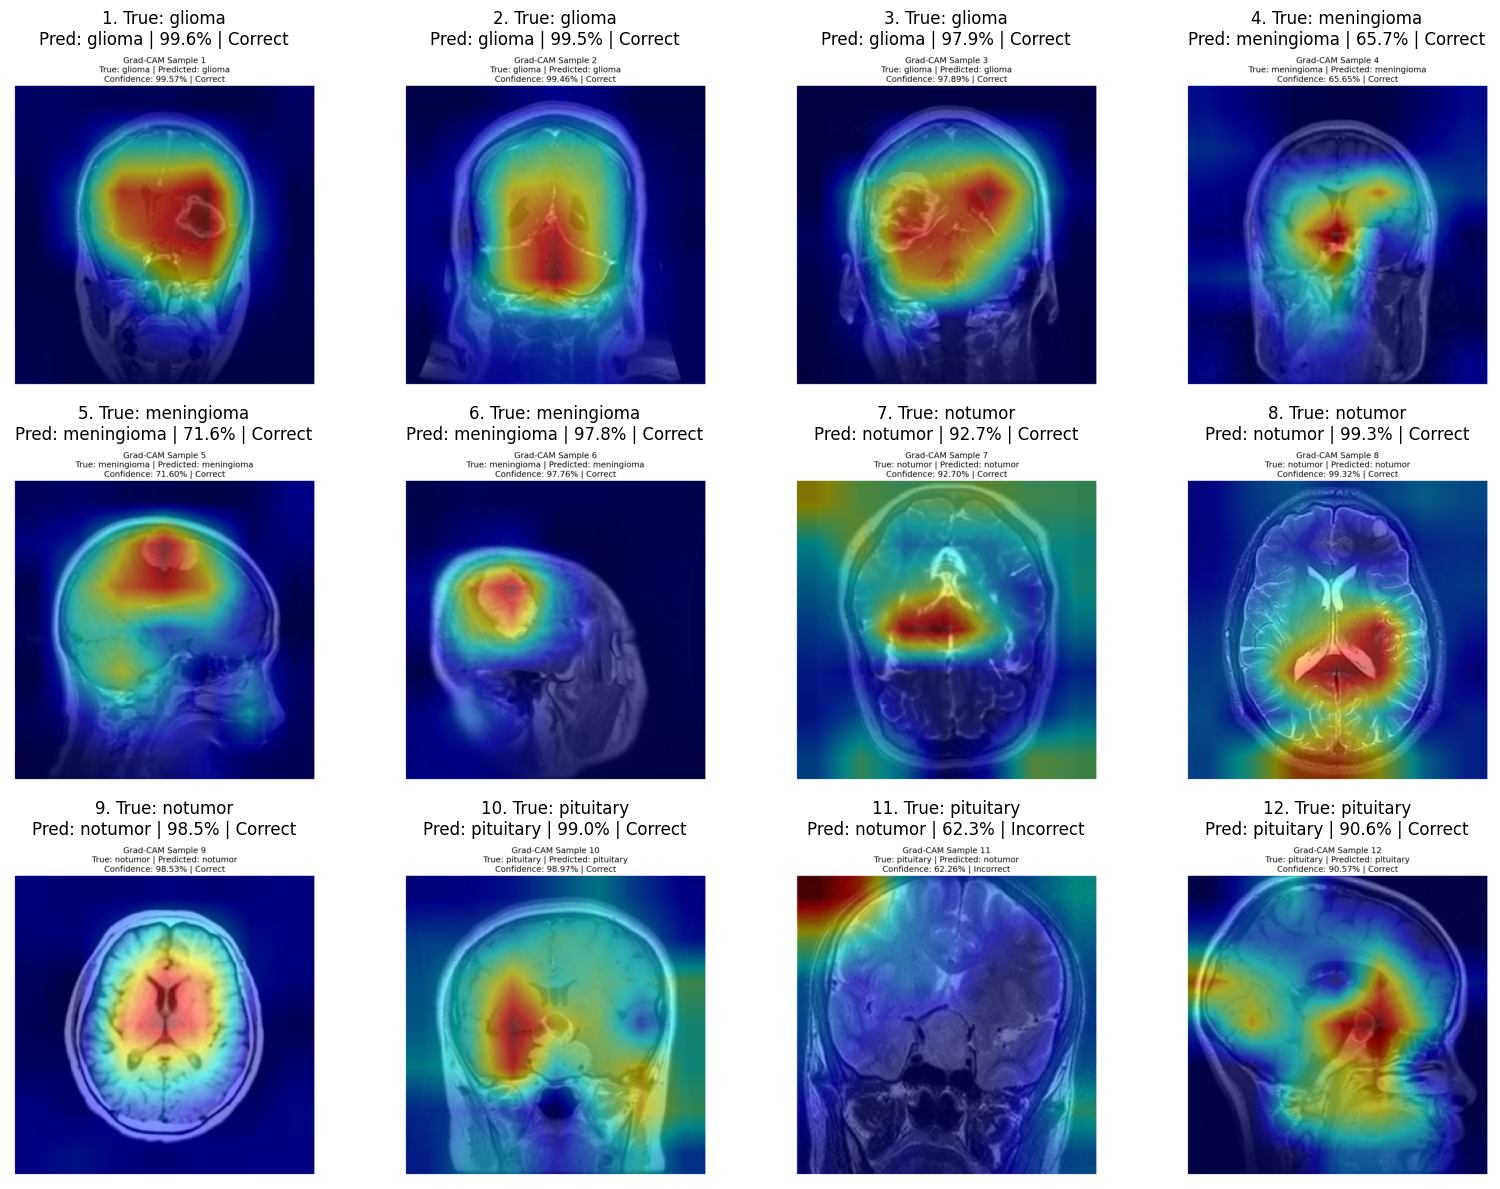


DAY 10 OUTPUT VERIFICATION COMPLETE
Grad-CAM samples : 12
Contact sheet    : /content/drive/MyDrive/MediScan/figures/day10_gradcam_contact_sheet.png
Metadata CSV     : /content/drive/MyDrive/MediScan/reports/day10_gradcam_samples.csv

✓ All Grad-CAM files verified
✓ Prediction metadata verified
✓ Contact sheet generated


In [8]:
# ============================================================
# DAY 10 — GRAD-CAM OUTPUT VERIFICATION
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")
FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"

metadata_path = REPORTS_DIR / "day10_gradcam_samples.csv"

# ------------------------------------------------------------
# 1. Load metadata
# ------------------------------------------------------------

gradcam_df = pd.read_csv(metadata_path)

print("=" * 60)
print("GRAD-CAM OUTPUT FILE VERIFICATION")
print("=" * 60)

print("Metadata rows:", len(gradcam_df))
print()

# ------------------------------------------------------------
# 2. Verify every generated image
# ------------------------------------------------------------

missing_files = []

for _, row in gradcam_df.iterrows():

    image_path = Path(row["figure_path"])

    if not image_path.exists():
        missing_files.append(image_path)

print("Expected Grad-CAM images :", len(gradcam_df))
print("Missing images            :", len(missing_files))

if missing_files:
    print("\nMissing files:")
    for path in missing_files:
        print("→", path)
else:
    print("✓ All Grad-CAM images exist")

# ------------------------------------------------------------
# 3. Verify image dimensions
# ------------------------------------------------------------

print()
print("=" * 60)
print("IMAGE DIMENSION VERIFICATION")
print("=" * 60)

dimensions_ok = True

for _, row in gradcam_df.iterrows():

    image_path = Path(row["figure_path"])

    if image_path.exists():

        with Image.open(image_path) as img:

            if img.width == 1050 and img.height == 1050:
                pass
            else:
                dimensions_ok = False
                print(
                    f"{image_path.name}: "
                    f"{img.size}"
                )

if dimensions_ok:
    print("✓ All saved figures have expected dimensions")

# ------------------------------------------------------------
# 4. Prediction summary
# ------------------------------------------------------------

print()
print("=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)

correct_count = int(gradcam_df["correct"].sum())
total_count = len(gradcam_df)

print("Correct predictions   :", correct_count)
print("Incorrect predictions :", total_count - correct_count)
print(
    "Sample accuracy       :",
    f"{correct_count / total_count:.2%}"
)

print()
print("Class-wise results:")
print(
    gradcam_df[
        ["true_class", "predicted_class", "confidence", "correct"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. Create verification contact sheet
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, (_, row) in enumerate(gradcam_df.iterrows()):

    image_path = Path(row["figure_path"])

    image = Image.open(image_path)

    axes[i].imshow(image)

    status = "Correct" if row["correct"] else "Incorrect"

    axes[i].set_title(
        f"{i+1}. True: {row['true_class']}\n"
        f"Pred: {row['predicted_class']} | "
        f"{row['confidence']:.1%} | {status}"
    )

    axes[i].axis("off")

plt.tight_layout()

contact_sheet_path = (
    FIGURES_DIR / "day10_gradcam_contact_sheet.png"
)

plt.savefig(
    contact_sheet_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

print()
print("=" * 60)
print("DAY 10 OUTPUT VERIFICATION COMPLETE")
print("=" * 60)

print("Grad-CAM samples :", total_count)
print("Contact sheet    :", contact_sheet_path)
print("Metadata CSV     :", metadata_path)

print()
print("✓ All Grad-CAM files verified")
print("✓ Prediction metadata verified")
print("✓ Contact sheet generated")

In [9]:
# ============================================================
# DAY 10 — GRAD-CAM ANALYSIS & SUMMARY REPORT
# ============================================================

from pathlib import Path
import pandas as pd
import json

# ------------------------------------------------------------
# 1. Restore paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = PROJECT_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Load Grad-CAM metadata
# ------------------------------------------------------------

metadata_path = REPORTS_DIR / "day10_gradcam_samples.csv"

gradcam_df = pd.read_csv(metadata_path)

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

# ------------------------------------------------------------
# 3. Calculate summary statistics
# ------------------------------------------------------------

total_samples = len(gradcam_df)

correct_samples = int(
    gradcam_df["correct"].sum()
)

incorrect_samples = (
    total_samples - correct_samples
)

sample_accuracy = (
    correct_samples / total_samples
)

average_confidence = (
    gradcam_df["confidence"].mean()
)

# ------------------------------------------------------------
# 4. Class-wise statistics
# ------------------------------------------------------------

class_summary = {}

for class_name in class_names:

    class_data = gradcam_df[
        gradcam_df["true_class"] == class_name
    ]

    class_summary[class_name] = {
        "samples": int(len(class_data)),
        "correct": int(class_data["correct"].sum()),
        "incorrect": int((~class_data["correct"]).sum()),
        "average_confidence": float(
            class_data["confidence"].mean()
        )
    }

# ------------------------------------------------------------
# 5. Identify incorrect predictions
# ------------------------------------------------------------

incorrect_df = gradcam_df[
    gradcam_df["correct"] == False
]

# ------------------------------------------------------------
# 6. Generate Markdown report
# ------------------------------------------------------------

report_lines = []

report_lines.append("# MediScan — Day 10 Grad-CAM Explainability")
report_lines.append("")

report_lines.append(
    "## Objective"
)
report_lines.append("")
report_lines.append(
    "Grad-CAM was implemented to visualize the image regions "
    "that contributed to the EfficientNet-B0 model's predicted "
    "class."
)
report_lines.append("")

report_lines.append(
    "## Grad-CAM Configuration"
)
report_lines.append("")
report_lines.append(
    "- Architecture: EfficientNet-B0"
)
report_lines.append(
    "- Dataset: Brain MRI classification"
)
report_lines.append(
    "- Number of classes: 4"
)
report_lines.append(
    "- Input resolution: 224 × 224"
)
report_lines.append(
    "- Target layer: Final feature block of EfficientNet-B0"
)
report_lines.append(
    "- Target class: Model's predicted class"
)
report_lines.append(
    "- Visualization: Grad-CAM heatmap overlaid on MRI image"
)
report_lines.append("")

report_lines.append(
    "## Explainability Samples"
)
report_lines.append("")
report_lines.append(
    f"A total of **{total_samples} Grad-CAM samples** were "
    "generated, with three samples selected from each class."
)
report_lines.append("")

for class_name in class_names:

    stats = class_summary[class_name]

    report_lines.append(
        f"- **{class_name}:** "
        f"{stats['samples']} samples, "
        f"{stats['correct']} correct, "
        f"{stats['incorrect']} incorrect"
    )

report_lines.append("")

report_lines.append(
    "## Sample Prediction Summary"
)
report_lines.append("")
report_lines.append(
    f"- Total Grad-CAM samples: **{total_samples}**"
)
report_lines.append(
    f"- Correct predictions: **{correct_samples}**"
)
report_lines.append(
    f"- Incorrect predictions: **{incorrect_samples}**"
)
report_lines.append(
    f"- Sample accuracy: **{sample_accuracy:.2%}**"
)
report_lines.append(
    f"- Average confidence: **{average_confidence:.2%}**"
)
report_lines.append("")

report_lines.append(
    "## Incorrect Prediction"
)
report_lines.append("")

if len(incorrect_df) > 0:

    for _, row in incorrect_df.iterrows():

        report_lines.append(
            f"- True class: **{row['true_class']}**"
        )
        report_lines.append(
            f"- Predicted class: **{row['predicted_class']}**"
        )
        report_lines.append(
            f"- Prediction confidence: "
            f"**{row['confidence']:.2%}**"
        )
        report_lines.append(
            f"- Grad-CAM visualization: "
            f"`{Path(row['figure_path']).name}`"
        )

else:

    report_lines.append(
        "No incorrect predictions were present in the "
        "selected explainability samples."
    )

report_lines.append("")

report_lines.append(
    "## Interpretation"
)
report_lines.append("")
report_lines.append(
    "The Grad-CAM heatmaps provide a visual indication of "
    "the image regions contributing to the model's prediction. "
    "They can help inspect whether the model is focusing on "
    "meaningful image regions rather than relying on obviously "
    "irrelevant areas."
)
report_lines.append("")
report_lines.append(
    "The generated examples include both correct and incorrect "
    "predictions. The incorrect pituitary example is particularly "
    "useful for qualitative inspection because the model predicted "
    "`notumor` instead of the true `pituitary` class."
)
report_lines.append("")

report_lines.append(
    "## Important Limitation"
)
report_lines.append("")
report_lines.append(
    "Grad-CAM is an explainability aid and should not be interpreted "
    "as proof that the highlighted region represents the actual "
    "clinical cause of a diagnosis. The visualization describes "
    "model behavior, not medical reasoning."
)
report_lines.append("")
report_lines.append(
    "This model is intended for research and educational purposes "
    "and is not a substitute for professional medical diagnosis."
)
report_lines.append("")

report_lines.append(
    "## Generated Artifacts"
)
report_lines.append("")
report_lines.append(
    "- `day10_gradcam_samples.csv` — Grad-CAM sample metadata"
)
report_lines.append(
    "- `day10_gradcam_sample_01...12.png` — 12 explainability samples"
)
report_lines.append(
    "- `day10_gradcam_contact_sheet.png` — combined visualization"
)
report_lines.append("")

report_lines.append(
    "## Day 10 Status"
)
report_lines.append("")
report_lines.append(
    "Grad-CAM implementation and explainability sample generation "
    "completed successfully."
)

# ------------------------------------------------------------
# 7. Save Markdown report
# ------------------------------------------------------------

report_path = REPORTS_DIR / "day10_gradcam_summary.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

# ------------------------------------------------------------
# 8. Save JSON summary
# ------------------------------------------------------------

json_summary = {
    "day": 10,
    "task": "Grad-CAM Explainability",
    "total_samples": total_samples,
    "correct_samples": correct_samples,
    "incorrect_samples": incorrect_samples,
    "sample_accuracy": sample_accuracy,
    "average_confidence": average_confidence,
    "class_summary": class_summary,
    "target_layer": "model.features[-1]",
    "num_classes": 4,
    "input_resolution": "224x224"
}

json_path = REPORTS_DIR / "day10_gradcam_summary.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        json_summary,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 9. Final output
# ------------------------------------------------------------

print("=" * 60)
print("DAY 10 GRAD-CAM REPORT COMPLETE")
print("=" * 60)

print()
print("Total samples       :", total_samples)
print("Correct samples     :", correct_samples)
print("Incorrect samples   :", incorrect_samples)
print("Sample accuracy     :", f"{sample_accuracy:.2%}")
print("Average confidence  :", f"{average_confidence:.2%}")

print()
print("Markdown report:")
print(report_path)

print()
print("JSON summary:")
print(json_path)

print()
print("✓ Grad-CAM analysis report saved")
print("✓ JSON summary saved")
print("✓ Day 10 explainability documentation complete")

DAY 10 GRAD-CAM REPORT COMPLETE

Total samples       : 12
Correct samples     : 11
Incorrect samples   : 1
Sample accuracy     : 91.67%
Average confidence  : 89.52%

Markdown report:
/content/drive/MyDrive/MediScan/reports/day10_gradcam_summary.md

JSON summary:
/content/drive/MyDrive/MediScan/reports/day10_gradcam_summary.json

✓ Grad-CAM analysis report saved
✓ JSON summary saved
✓ Day 10 explainability documentation complete
